In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [39]:
df = pd.read_csv('pendigits_txt.csv')
df.head(5)

,input1,input2,input3,input4,input5,input6,input7,input8,input9,input10,input11,input12,input13,input14,input15,input16,class
0,47,100,27,81,57,37,26,0,0,23,56,53,100,90,40,98,8
1,0,89,27,100,42,75,29,45,15,15,37,0,69,2,100,6,2
2,0,57,31,68,72,90,100,100,76,75,50,51,28,25,16,0,1
3,0,100,7,92,5,68,19,45,86,34,100,45,74,23,67,0,4
4,0,67,49,83,100,100,81,80,60,60,40,40,33,20,47,0,1


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10992 entries, 0 to 10991
Data columns (total 17 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   input1   10992 non-null  int64
 1   input2   10992 non-null  int64
 2   input3   10992 non-null  int64
 3   input4   10992 non-null  int64
 4   input5   10992 non-null  int64
 5   input6   10992 non-null  int64
 6   input7   10992 non-null  int64
 7   input8   10992 non-null  int64
 8   input9   10992 non-null  int64
 9   input10  10992 non-null  int64
 10  input11  10992 non-null  int64
 11  input12  10992 non-null  int64
 12  input13  10992 non-null  int64
 13  input14  10992 non-null  int64
 14  input15  10992 non-null  int64
 15  input16  10992 non-null  int64
 16  class    10992 non-null  int64
dtypes: int64(17)
memory usage: 1.4 MB


In [41]:
df.describe()

,input1,input2,input3,input4,input5,input6,input7,input8,input9,input10,input11,input12,input13,input14,input15,input16,class
count,10992.000000,10992.000000,10992.000000,10992.000000,10992.000000,10992.000000,10992.000000,10992.000000,10992.000000,10992.000000,10992.000000,10992.000000,10992.000000,10992.000000,10992.000000,10992.000000,10992.000000
mean,38.814320,85.120269,40.605622,83.774199,49.770378,65.573144,51.220251,44.498999,56.868541,33.695961,60.516376,34.826510,55.022289,34.937045,47.287482,28.845342,4.431587
std,34.257783,16.218571,26.342984,19.163646,34.100515,26.996688,30.576881,29.906104,34.135530,27.251548,37.288086,27.119982,22.335539,33.155463,41.760400,35.778094,2.876947
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,76.000000,20.000000,72.000000,18.000000,49.000000,28.000000,23.000000,29.000000,7.000000,23.000000,11.000000,42.000000,5.000000,0.000000,0.000000,2.000000
50%,32.000000,89.000000,40.000000,91.000000,53.000000,71.000000,53.500000,43.000000,60.000000,33.000000,73.000000,30.000000,53.000000,27.000000,40.000000,9.000000,4.000000
75%,65.000000,100.000000,58.000000,100.000000,78.000000,86.000000,74.000000,64.000000,89.000000,54.000000,97.000000,55.000000,68.000000,47.000000,100.000000,51.000000,7.000000
max,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,9.000000


In [42]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [43]:
X.shape

(10992, 16)

In [44]:
y.shape

(10992,)

In [45]:
from sklearn.metrics import classification_report,accuracy_score

In [46]:
from sklearn.model_selection import train_test_split, GridSearchCV
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=41)

In [47]:
from sklearn.tree import DecisionTreeClassifier,plot_tree
clf = DecisionTreeClassifier()

# Without Hyperparameter tuning 

In [48]:
clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [49]:
y_pred_noTuning = clf.predict(X_test)

In [50]:
print(f"Accuracy score without Hyperparameter tuning : {accuracy_score(y_test, y_pred_noTuning)}")

Accuracy score without Hyperparameter tuning : 0.9586175534333788


# With hyperparameter tuning

In [51]:
param_dict = {
    'max_depth':[4,6,8,None],
    'min_samples_split':[10,8]
}

In [52]:
grid = GridSearchCV(
    estimator=DecisionTreeClassifier(),
    param_grid=param_dict,
    cv=5,
    n_jobs=-1
)

In [53]:
grid.fit(X_train, y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'max_depth': [4, 6, ...], 'min_samples_split': [10, 8]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [54]:
y_pred = grid.predict(X_test)

In [55]:
print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       220
           1       0.95      0.92      0.93       225
           2       0.95      0.96      0.95       225
           3       0.96      0.98      0.97       215
           4       0.93      0.98      0.96       229
           5       0.95      0.93      0.94       216
           6       0.96      0.97      0.97       231
           7       0.95      0.94      0.95       224
           8       0.95      0.97      0.96       212
           9       0.96      0.92      0.94       202

    accuracy                           0.96      2199
   macro avg       0.96      0.96      0.96      2199
weighted avg       0.96      0.96      0.96      2199

0.9554342883128695


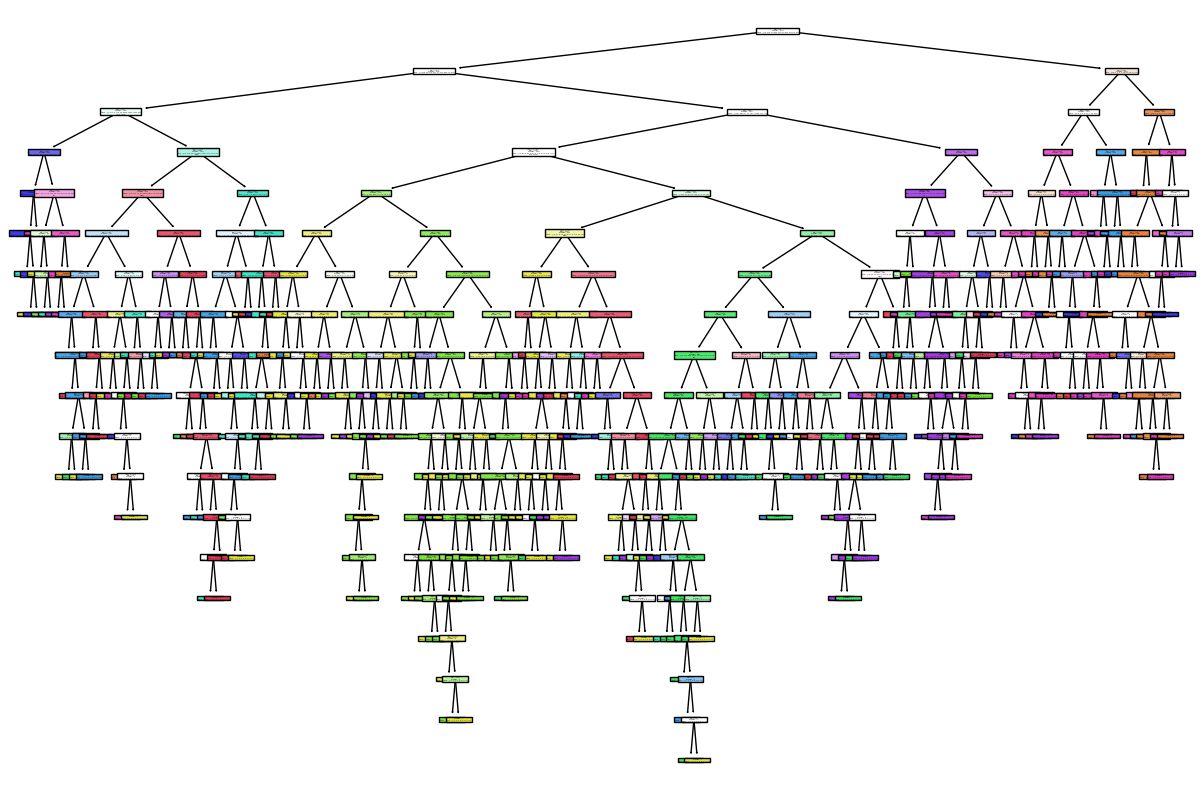

In [56]:
from sklearn import tree
import matplotlib.pyplot as plt


plt.figure(figsize=(15,10))
tree.plot_tree(clf, feature_names=X.columns, filled=True)
plt.show()

In [57]:
y_pred.shape

(2199,)

In [58]:
y_pred[100]

np.int64(4)

In [59]:
print(type(X_test))

<class 'pandas.core.frame.DataFrame'>


In [60]:
print(X_test.shape)

(2199, 16)


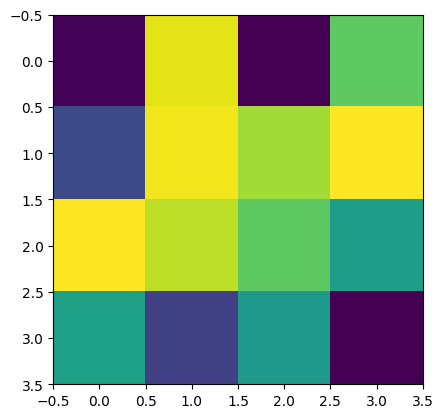

In [61]:
plt.imshow(X_test.iloc[80].values.reshape(4, 4))         #NOTE: since panda dataframe so use .iloc

# Model

In [62]:
import numpy as np

coordinates = [30,90,60,90,80,70,60,60,80,40,60,30,40,20,60,10]

test = np.array(coordinates).reshape(1,16)

prediction = grid.predict(test)

print("Predicted digit:", prediction[0])

Predicted digit: 9


/Users/bheshu/Desktop/Machine Learning/ML_ENV/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
